In [4]:
!pip install pandas numpy matplotlib 



In [5]:
!pip install seaborn



In [6]:
import pandas as pd

df = pd.read_csv("C:/Users/DELL/Downloads/mental_health_dataset.csv")

df.head()

,Student_ID,Age,Gender,GPA,Stress_Level,Anxiety_Score,Depression_Score,Daily_Reflections,Sleep_Hours,Steps_Per_Day,Mood_Description,Sentiment_Score,Mental_Health_Status
0,1,23,Other,2.52,5,20,6,Onto foreign do environmental anyone every nea...,6.8,4166,Happy,0.0000,2
1,2,19,Male,2.74,5,3,7,Party but others visit admit industry country ...,5.1,4949,Tired,0.4678,2
2,3,21,Female,3.53,5,11,24,Religious sure wait do chance decade according...,8.3,7632,Sad,0.5106,2
3,4,18,Male,2.04,4,15,14,A task effect entire coach join series.,8.2,5548,Sad,0.2960,2
4,5,19,Other,2.87,1,2,4,Knowledge several camera wait week write quali...,5.9,3698,Happy,0.4588,0


In [7]:
df.shape

(500, 13)

In [8]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'GPA', 'Stress_Level', 'Anxiety_Score',
       'Depression_Score', 'Daily_Reflections', 'Sleep_Hours', 'Steps_Per_Day',
       'Mood_Description', 'Sentiment_Score', 'Mental_Health_Status'],
      dtype='object')

In [9]:
df.isnull().sum()

Student_ID              0
Age                     0
Gender                  0
GPA                     0
Stress_Level            0
Anxiety_Score           0
Depression_Score        0
Daily_Reflections       0
Sleep_Hours             0
Steps_Per_Day           0
Mood_Description        0
Sentiment_Score         0
Mental_Health_Status    0
dtype: int64

In [10]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


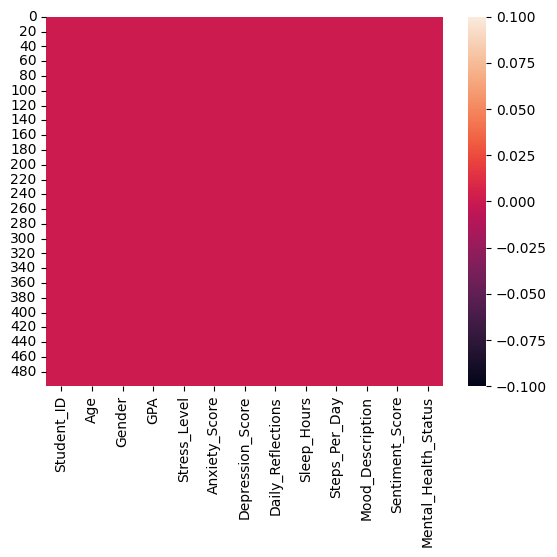

In [11]:
import seaborn as sns 
import matplotlib.pyplot as pt

sns.heatmap(df.isnull())
pt.show()

In [12]:
df['Sleep_hours']= df['Sleep_Hours'].fillna (df['Sleep_Hours'].median())

In [13]:
df['Gender']=df['Gender'].fillna (df['Gender'].mode()[0])

In [14]:
!python -m pip install --upgrade pip
!pip install scikit-learn

In [15]:
print(df.dtypes)

Student_ID                int64
Age                       int64
Gender                   object
GPA                     float64
Stress_Level              int64
Anxiety_Score             int64
Depression_Score          int64
Daily_Reflections        object
Sleep_Hours             float64
Steps_Per_Day             int64
Mood_Description         object
Sentiment_Score         float64
Mental_Health_Status      int64
Sleep_hours             float64
dtype: object


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

In [17]:
X=df.drop('Depression_Score',axis=1)
y=df['Depression_Score']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
model = RandomForestClassifier()

In [21]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
predictions = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.04


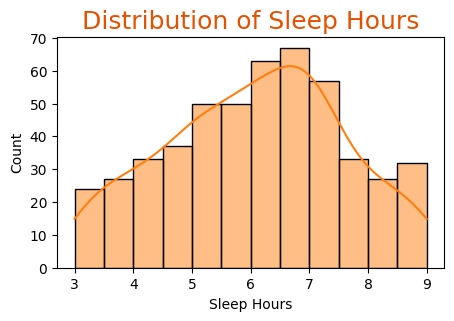

In [24]:
pt.figure(figsize=(5,3))

sns.histplot(
    df['Sleep_Hours'],
    kde=True,
    color='#FF7F0E'   # bright orange
)

pt.title("Distribution of Sleep Hours", fontsize=18, color='#E65100')
pt.xlabel("Sleep Hours")
pt.ylabel("Count")

pt.show()

In [25]:
sns.set_style("whitegrid")
sns.set_palette("pastel")

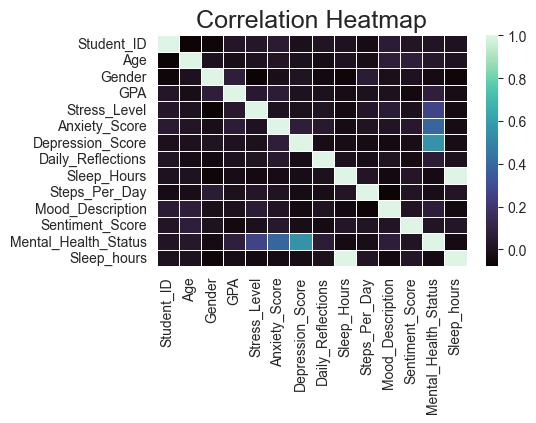

In [26]:
pt.figure(figsize=(5,3))

sns.heatmap(
    df.corr(),
    annot=False,
    cmap="mako",
    linewidths=0.5
)

pt.title("Correlation Heatmap", fontsize=18)
pt.show()

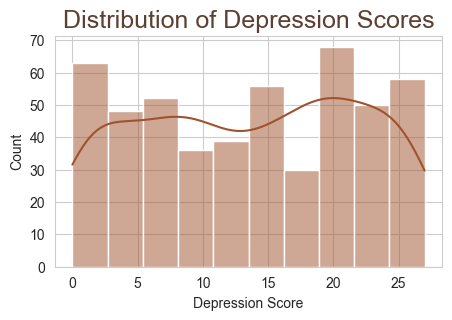

In [27]:
pt.figure(figsize=(5,3))

sns.histplot(
    df['Depression_Score'],
    kde=True,
    color="#A0522D"   # warm cookie brown
)

pt.title(
    "Distribution of Depression Scores",
    fontsize=18,
    color="#5C4033"
)

pt.xlabel("Depression Score")
pt.ylabel("Count")


pt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8128\1153639034.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_8128\1153639034.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(


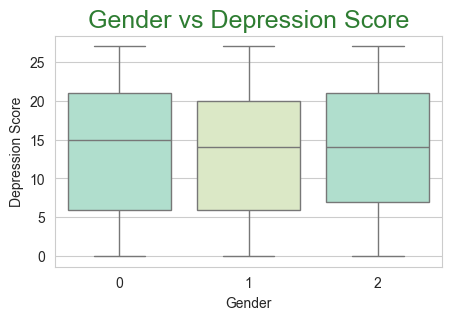

In [28]:
pt.figure(figsize=(5,3))

sns.boxplot(
    x='Gender',
    y='Depression_Score',
    data=df,
    palette=['#A8E6CF', '#Dcedc1']  # pastel green shades
)

pt.title("Gender vs Depression Score", fontsize=18, color='#2E7D32')
pt.xlabel("Gender")
pt.ylabel("Depression Score")

pt.show()

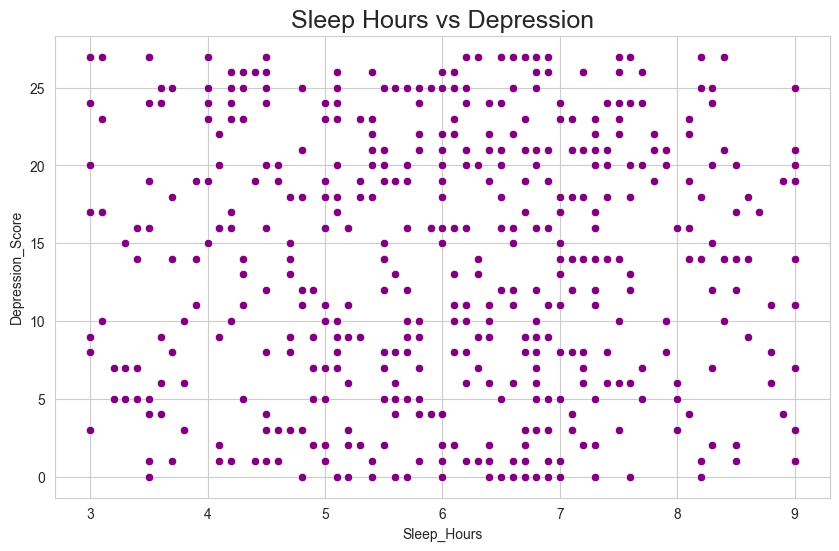

In [29]:
pt.figure(figsize=(10,6))

sns.scatterplot(
    x='Sleep_Hours',
    y='Depression_Score',
    data=df,
    color='purple'
)

pt.title("Sleep Hours vs Depression", fontsize=18)

pt.show()

In [2]:
importance = model.feature_importances_

feature_importance = pd.Series(
    importance,
    index=X.columns
)

feature_importance = feature_importance.sort_values()

pt.figure(figsize=(10,7))

feature_importance.plot(
    kind='barh',
    color='teal'
)

pt.title("Feature Importance", fontsize=18)


pt.show()

NameError: name 'model' is not defined

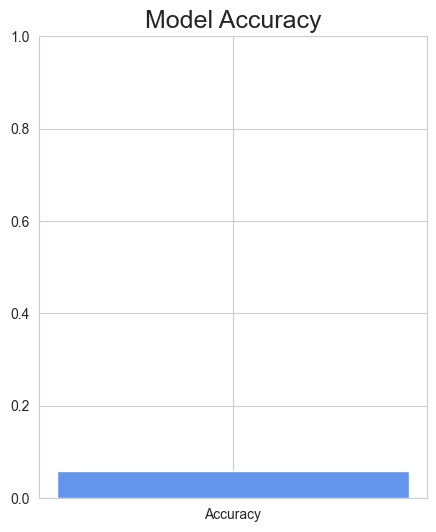

In [43]:
accuracy = accuracy_score(y_test, predictions)

pt.figure(figsize=(5,6))

pt.bar(
    ['Accuracy'],
    [accuracy],
    color='cornflowerblue'
)

pt.ylim(0,1)

pt.title("Model Accuracy", fontsize=18)

pt.show()